# Imports

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import unicodedata
import json

# Read Data File

In [39]:
file = "data_zhou.xlsx"
xls = pd.ExcelFile(file)

print(xls.sheet_names)

['Case 1 LZ50 steel', 'Case 2 SLM 316l', 'Case 3 7075_T6_ratio', 'Case 4 Al2024_T4', 'Case 4 Al7175_T7511', 'Case 4 Ti-4.5Al-3V-2Fe-2Mo', 'Case4 ZK60A-T5', 'Case 5 AMS 5707', 'Case 6 Inconel 718', 'Case 7 7075_T6_mean', 'Case 8 Al-Mg4.5-Mn', 'Case Ti-6.5Al-2Zr-Mo-V']


# Exploratory Data Analysis 

In [40]:
all_sheets = pd.read_excel(file, sheet_name=None)

for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):
    print(f"\nDataset {i}")
    print("Sheet:", sheet_name)


Dataset 1
Sheet: Case 1 LZ50 steel

Dataset 2
Sheet: Case 2 SLM 316l

Dataset 3
Sheet: Case 3 7075_T6_ratio

Dataset 4
Sheet: Case 4 Al2024_T4

Dataset 5
Sheet: Case 4 Al7175_T7511

Dataset 6
Sheet: Case 4 Ti-4.5Al-3V-2Fe-2Mo

Dataset 7
Sheet: Case4 ZK60A-T5

Dataset 8
Sheet: Case 5 AMS 5707

Dataset 9
Sheet: Case 6 Inconel 718

Dataset 10
Sheet: Case 7 7075_T6_mean

Dataset 11
Sheet: Case 8 Al-Mg4.5-Mn

Dataset 12
Sheet: Case Ti-6.5Al-2Zr-Mo-V


In [41]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):

    print("\n" + "="*60)
    print(f"Sheet {i}: {sheet_name}")
    print("="*60)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst rows:")
    print(df.head())

    print("\nMissing values:")
    print(df.isnull().sum())


Sheet 1: Case 1 LZ50 steel

Shape:
(63, 4)

Columns:
['Stress/MPa', 'Fatigue life/cycles', 'log life', 'temperature/K']

First rows:
   Stress/MPa  Fatigue life/cycles  log life  temperature/K
0         353                89226  4.950491            293
1         340               122326  5.087519            293
2         340               124990  5.096875            293
3         340               114325  5.058141            293
4         340               100206  5.000894            293

Missing values:
Stress/MPa             0
Fatigue life/cycles    0
log life               0
temperature/K          0
dtype: int64

Sheet 2: Case 2 SLM 316l

Shape:
(44, 5)

Columns:
['Stress(MPa)', 'Î”K (MPaâˆšm)', 'Dmax', 'L/Leff', 'Nf']

First rows:
   Stress(MPa)  Î”K (MPaâˆšm)  Dmax  L/Leff      Nf
0          400           4.05    95    1.01  256343
1          400           4.54   117    1.00  197813
2          360           3.34    80    1.00  386505
3          360           4.29   132    1.00  3

None of the datasets contain missing values, so we can proceed.

# Clean Data

## Standarize Column Names

In [42]:
# standardize column names across datasets
for sheet_name, df in all_sheets.items():
    
    rename_map = {
        "stress(mpa)": "stress_max",
        "stress_mpa": "stress_max",
        "stressmpa": "stress_max",
        "s_mpa": "stress_max",
        "sa_mpa": "stress_amp",
        "cycles": "Nf",
        "fatigue_life": "Nf",
        "n": "Nf",
        "nf": "Nf",
        "î”k_(mpaâˆšm)": "deltaK",
        "ik_mpaasm": "deltaK",
        "dmax": "sqrt_A",
        "r": "r-ratio",
        "rratio": "r-ratio",
        "t": "temperature_k",
        "kt": "Kt"
    }

    symbol_map = {
        "σ": "s",
        "Δ": "delta",
        "µ": "micro",
        "√": "sqrt",
    }
    
    # df = df.rename(columns=rename_map)

    # print(df.columns.to_list())

In [43]:
# cleanup column names across datasets
cleaned_sheets = {}

for sheet_name, df in all_sheets.items():
    
    cleaned_cols = []
    
    for col in df.columns:

        col = str(col)

        # replace Greek letters for readability
        for symbol, replacement in symbol_map.items():
            col = col.replace(symbol, replacement)

        # clean column names
        col = unicodedata.normalize("NFKD", col)
        col = col.encode("ascii", "ignore").decode()
        col = col.strip().lower().replace(" ", "_").replace("/", "_").strip("_")
        col = re.sub(r"[^a-z0-9_]", "", col)
        col = re.sub(r"_+", "_", col)

        cleaned_cols.append(col)

    df.columns = cleaned_cols

    # rename columns to standardize across datasets
    df = df.rename(columns=rename_map)

    cleaned_sheets[sheet_name] = df

    # print column names after cleaning and renaming
    print(df.columns.tolist())

['stress_max', 'fatigue_life_cycles', 'log_life', 'temperature_k']
['stress_max', 'deltaK', 'sqrt_A', 'l_leff', 'Nf']
['stress_max', 'r-ratio', 'Nf']
['stress_max', 'r-ratio', 'Kt', 'Nf']
['stress_max', 'r-ratio', 'Kt', 'Nf']
['stress_max', 'r-ratio', 'Kt', 'Nf']
['stress_max', 'r-ratio', 'Kt', 'Nf']
['stress_amp', 'Nf', 'r-ratio', 'temperature_k']
['stress_max', 'r-ratio', 'Kt', 'temperature_k', 'Nf']
['stress_max', 'mean_stress_mpa', 'Kt', 'Nf']
['stress_max', 'defect_size_m', 'defect_position_m', 'Nf']
['stress_max', 'defect_size_m', 'defect_position_m', 'Nf']


# Build Dataset Dictionary

In [44]:
# create a dictionary to store the datasets and their metadata
datasets = {}

category_map = {
    1: "fatigue_life",
    2: "fracture_mechanics",
    3: "fatigue_life",
    4: "stress_concentration",
    5: "stress_concentration",
    6: "stress_concentration",
    7: "stress_concentration",
    8: "fatigue_life",
    9: "stress_concentration",
    10: "stress_concentration",
    11: "defect_informed",
    12: "defect_informed",
}

material_map = {
    1: "LZ50 steel",
    2: "SLM 316L",
    3: "Al7075-T6",
    4: "Al2024",
    5: "Al7175",
    6: "Ti-4.5Al-3V-2Fe-2Mo",
    7: "ZK60A-T5",
    8: "AMS 5707",
    9: "Inconel 718",
    10: "Al7075-T6",
    11: "Al-Mg4.5-Mn",
    12: "Ti-6.5Al-2Zr-Mo-V",
}

for i, (sheet_name, df) in enumerate(cleaned_sheets.items(), start=1):

    datasets[sheet_name] = {
        "data": df,
        "case": i,
        "material": material_map.get(i),
        "category": category_map.get(i),
        "n_samples": len(df),
        "columns": list(df.columns),
        "target": "Nf" if "Nf" in df.columns else None,
        "input_features": [col for col in df.columns if col != "Nf"],
        "physics_features": [
            col for col in df.columns 
            if col in ["deltaK", "sqrt_A", "Kt", "r-ratio", "defect_size_m"]
        ],
        "notes": ""
    }

# for sheet_name, df in cleaned_sheets.items():

#     datasets[sheet_name] = {
#         "data": df,
#         "n_samples": len(df),
#         "columns": list(df.columns),
#         "target": "Nf",
#         "material": None,
#         "category": None
#     }

In [45]:
# print summary of datasets
for name, info in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("Case:", info["case"])
    print("Material:", info["material"])
    print("Category:", info["category"])
    print("Samples:", info["n_samples"])
    print("Inputs:", info["input_features"])
    print("Physics:", info["physics_features"])


Case 1 LZ50 steel
Case: 1
Material: LZ50 steel
Category: fatigue_life
Samples: 63
Inputs: ['stress_max', 'fatigue_life_cycles', 'log_life', 'temperature_k']
Physics: []

Case 2 SLM 316l
Case: 2
Material: SLM 316L
Category: fracture_mechanics
Samples: 44
Inputs: ['stress_max', 'deltaK', 'sqrt_A', 'l_leff']
Physics: ['deltaK', 'sqrt_A']

Case 3 7075_T6_ratio
Case: 3
Material: Al7075-T6
Category: fatigue_life
Samples: 133
Inputs: ['stress_max', 'r-ratio']
Physics: ['r-ratio']

Case 4 Al2024_T4
Case: 4
Material: Al2024
Category: stress_concentration
Samples: 120
Inputs: ['stress_max', 'r-ratio', 'Kt']
Physics: ['r-ratio', 'Kt']

Case 4 Al7175_T7511
Case: 5
Material: Al7175
Category: stress_concentration
Samples: 266
Inputs: ['stress_max', 'r-ratio', 'Kt']
Physics: ['r-ratio', 'Kt']

Case 4 Ti-4.5Al-3V-2Fe-2Mo
Case: 6
Material: Ti-4.5Al-3V-2Fe-2Mo
Category: stress_concentration
Samples: 61
Inputs: ['stress_max', 'r-ratio', 'Kt']
Physics: ['r-ratio', 'Kt']

Case4 ZK60A-T5
Case: 7
Material: 

In [46]:
# # add each sheet to dictionary

# # fatigue life datasets
# # sheets 1, 3, 8

# # Sheet 1: Case 1 LZ50 steel
# datasets["SLZ50 steel"] = {
#     "data": df,
#     "category": "fatigue_life",
#     "material": "SLZ50 steel",
#     "target": "Nf",
#     "input_features": [
#         "temperature_k",
#         "",
#         "sqrt_A"
#     ],
#     "physics_features": [
#         "Nf"
#     ],
#     "notes": "Contains XCT-derived defect sizes"
# }

# # Sheet 2: Case 2 SLM 316l
# datasets["SLM_316L"] = {
#     "data": df,
#     "category": "fatigue_life",
#     "material": "SLM 316L",
#     "target": "Nf",
#     "input_features": [
#         "stress_amp",
#         "r-ratio",
#         "sqrt_A"
#     ],
#     "physics_features": [
#         "deltaK"
#     ],
#     "notes": "Contains XCT-derived defect sizes"
# }

In [47]:
# # add metadata for each dataset
# datasets["Case 1 LZ50 steel"]["material"] = "LZ50 steel"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 2 SLM 316l"]["material"] = "SLM 316L"
# datasets["Case 1 LZ50 steel"]["category"] = ""

# datasets["Case 3 7075_T6_ratio"]["material"] = "7075_T6_ratio"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Al2024_T4"]["material"] = "Al2024_T4"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Al7175_T7511"]["material"] = "Al7175_T7511"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Ti-4.5Al-3V-2Fe-2Mo"]["material"] = "Ti-4.5Al-3V-2Fe-2Mo"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case4 ZK60A-T5"]["material"] = "ZK60A-T5"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 5 AMS 5707"]["material"] = "AMS 5707"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# Explore Each Sheet

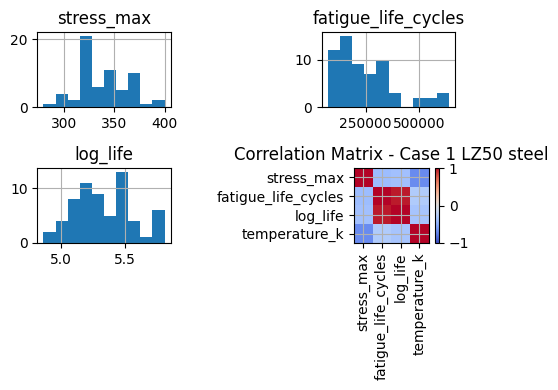

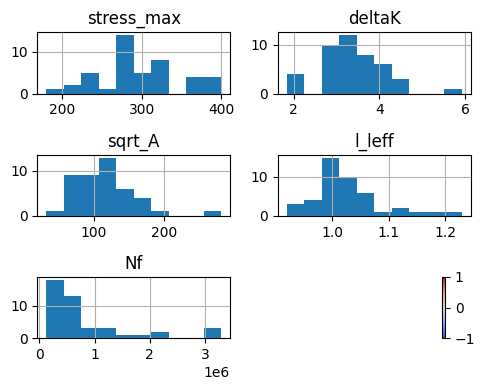

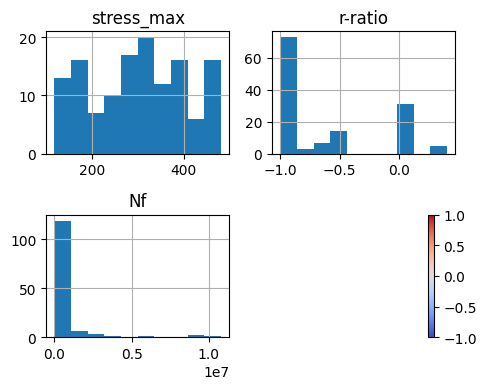

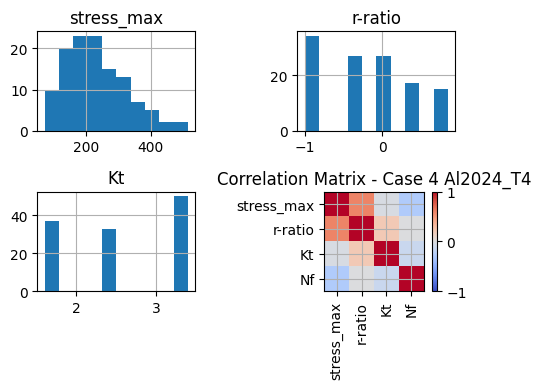

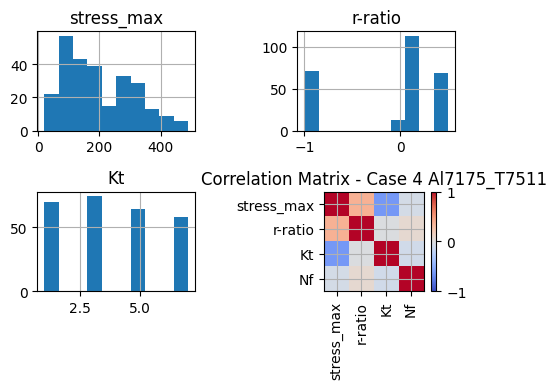

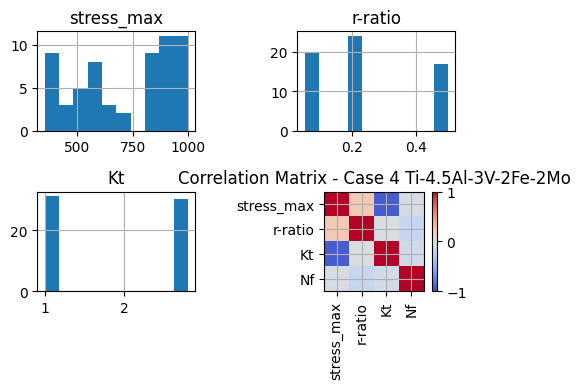

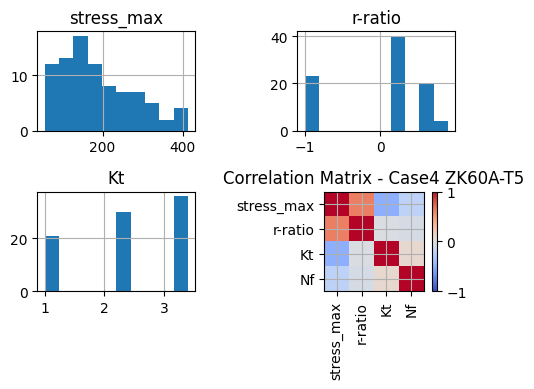

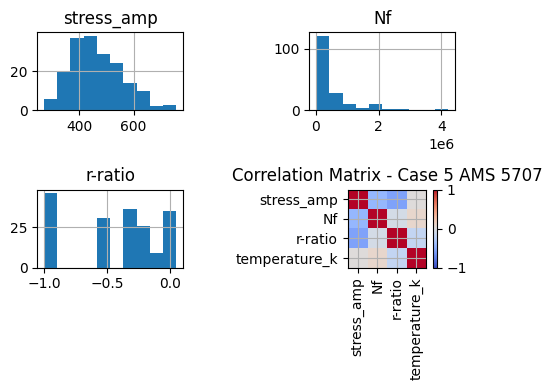

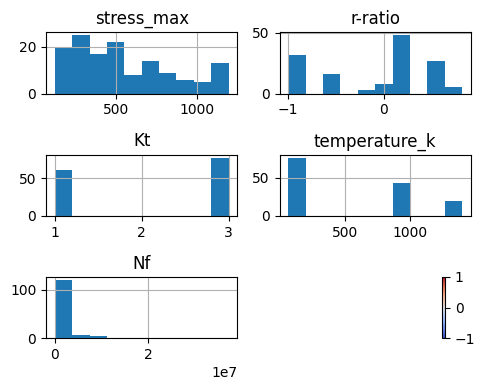

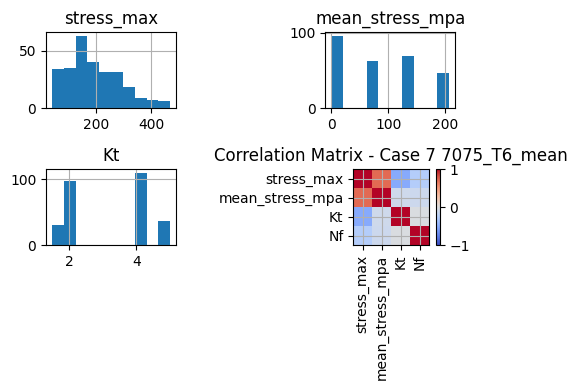

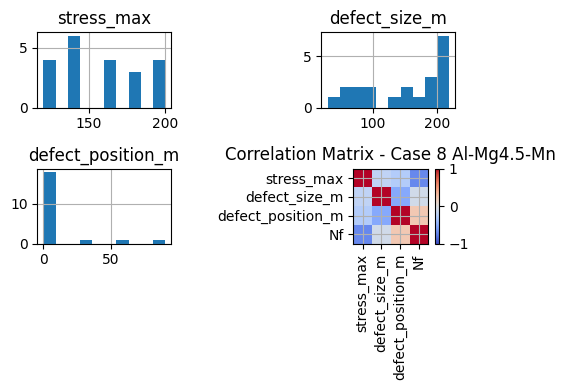

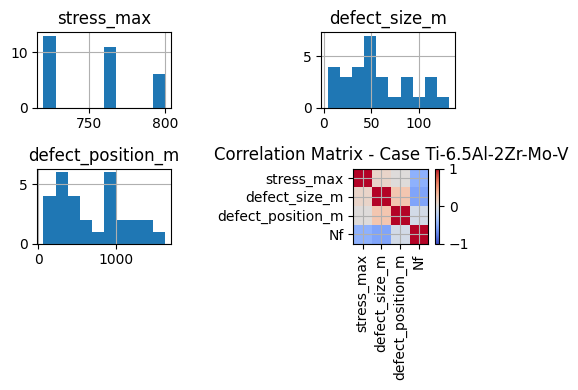

In [48]:
for i, (sheet_name, df) in enumerate(cleaned_sheets.items(), start=1):

    #numerical summary
    df.describe()

    # histograms of numerical columns
    df.hist(figsize=(5,4))

    # correlation matrix
    corr = df.corr(numeric_only=True)

    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title(f"Correlation Matrix - {sheet_name}")
    plt.tight_layout()
    plt.show()

# Export Clean Sheet

In [49]:
# export cleaned sheets to one Excel workbook
with pd.ExcelWriter("data_zhou_cleaned.xlsx") as writer:
    for sheet_name, df in cleaned_sheets.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

In [50]:
# metadata only, without the actual dataframe objects
metadata = {}

for sheet_name, info in datasets.items():
    metadata[sheet_name] = {
        key: value
        for key, value in info.items()
        if key != "data"
    }

with open("data_zhou_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)